# Level 3 — Skin wound CellCharter spatial niches (plot-only)

The heavy CellCharter pipeline (scVI batch correction → Delaunay spatial neighbors →
neighborhood aggregation → GMM niche sweep) was **already run once** and saved to
`../../data/talbot_xenium_skin_annotated_cellcharter.h5ad`.

This notebook simply **loads that pre-computed object and plots the spatial niche
maps**, mirroring the tumor `04_cellcharter` notebook. It does *not* re-run scVI or
the GMM sweep (those take ~30 min on CPU). The full generating pipeline is kept at
the bottom as a non-executed reproducibility appendix.

Object contents: `CellCharter_8/10/12` niche labels, `obsm['spatial']`,
`obsm['X_scVI']`, `obsm['X_cellcharter']`, and `cytetype_annotation_leiden_4`.

In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.lines import Line2D
import warnings; warnings.filterwarnings('ignore')

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Load the pre-computed CellCharter object

In [2]:
adata = sc.read_h5ad('../../data/talbot_xenium_skin_annotated_cellcharter.h5ad')
adata

AnnData object with n_obs × n_vars = 77401 × 5006
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'sample_folder', 'sample___', 'condition', 'tissue', 'genotype', 'timepoint', 'seg_method_short', 'n_genes_by_counts', 'sample_id', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_1.5', 'leiden_2', 'leiden_2.5', 'leiden_3', 'leiden_3.5', 'leiden_4', 'cytetype_annotation_leiden_4', 'cytetype_cellOntologyTerm_leiden_4', '_scvi_batch', '_scvi_labels', 'CellCharter_8', 'CellCharter_10', 'CellCharter_12'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'gene_symbols'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cytetype_annotation_leiden_4_colors', 'cytetype_jobDetails', 'cytetype_results', 'genotype_colors', 'lei

In [3]:
KS = [8, 10, 12]
ANNOT = 'cytetype_annotation_leiden_4'
niche_cols = [f'CellCharter_{k}' for k in KS]
for c in niche_cols:
    print(c, '->', adata.obs[c].nunique(), 'niches')

# BIC/AIC sweep that selected the niche counts (written by the original run)
sweep_path = '../../results/cell-driven-analysis/skin_wound_cellcharter_gmm_sweep.csv'
if os.path.exists(sweep_path):
    sweep = pd.read_csv(sweep_path)
    display(sweep)
    print('best k by BIC =', int(sweep.loc[sweep.bic.idxmin(), 'k']))

CellCharter_8 -> 8 niches
CellCharter_10 -> 10 niches
CellCharter_12 -> 12 niches


,k,bic,aic
0,8,2.587000e+06,2523249.0
1,10,2.499182e+06,2419491.0
2,12,2.459705e+06,2364073.8


best k by BIC = 12


## Spatial niche maps — per sample (like tumor `04_cellcharter`)

One panel per `sample_id`, cells colored by niche. This is the tumor-style
per-sample grid, self-contained (no external MANA util dependency).

In [4]:
def plot_niches_by_sample(ad, color, out_stem=None, groupby='sample_id',
                          spot_size=3, cols=6, height=2.6, dpi=110, title=None):
    """Per-sample grid of spatial niche maps (tumor-style)."""
    coords = np.asarray(ad.obsm['spatial'])[:, :2]
    cats = ad.obs[color].astype('category')
    names = list(cats.cat.categories)
    codes = cats.cat.codes.to_numpy()
    base = list(plt.get_cmap('tab20').colors)
    col_list = (base * int(np.ceil(len(names) / len(base))))[:len(names)]
    rgba = np.array([mcolors.to_rgba(c) for c in col_list])

    samples = list(pd.unique(ad.obs[groupby].astype(str)))
    n = len(samples)
    ncol = min(cols, n)
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * height, nrow * height), dpi=dpi)
    axes = np.atleast_1d(axes).ravel()
    sid = ad.obs[groupby].astype(str).to_numpy()
    for ax, s in zip(axes, samples):
        m = sid == s
        cc = codes[m]
        ax.scatter(coords[m, 0], coords[m, 1], s=spot_size,
                   c=rgba[cc[cc >= 0]], linewidths=0, rasterized=True)
        ax.set_title(s, fontsize=8)
        ax.set_aspect('equal'); ax.invert_yaxis(); ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    handles = [Line2D([0], [0], marker='o', linestyle='', markersize=6,
                      markerfacecolor=rgba[i], markeredgewidth=0, label=nm)
               for i, nm in enumerate(names)]
    fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5),
               fontsize=7, frameon=False, title=color)
    if title:
        fig.suptitle(title, fontsize=11, y=1.02)
    fig.tight_layout()
    if out_stem:
        os.makedirs(os.path.dirname(out_stem), exist_ok=True)
        fig.savefig(out_stem + '.png', dpi=dpi, bbox_inches='tight')
        fig.savefig(out_stem + '.pdf', bbox_inches='tight')
        print('saved', out_stem + '.png/.pdf')
    plt.show()

saved ../../results/spatial-tissue-maps/skin_wound_niches_k8_by_sample.png/.pdf


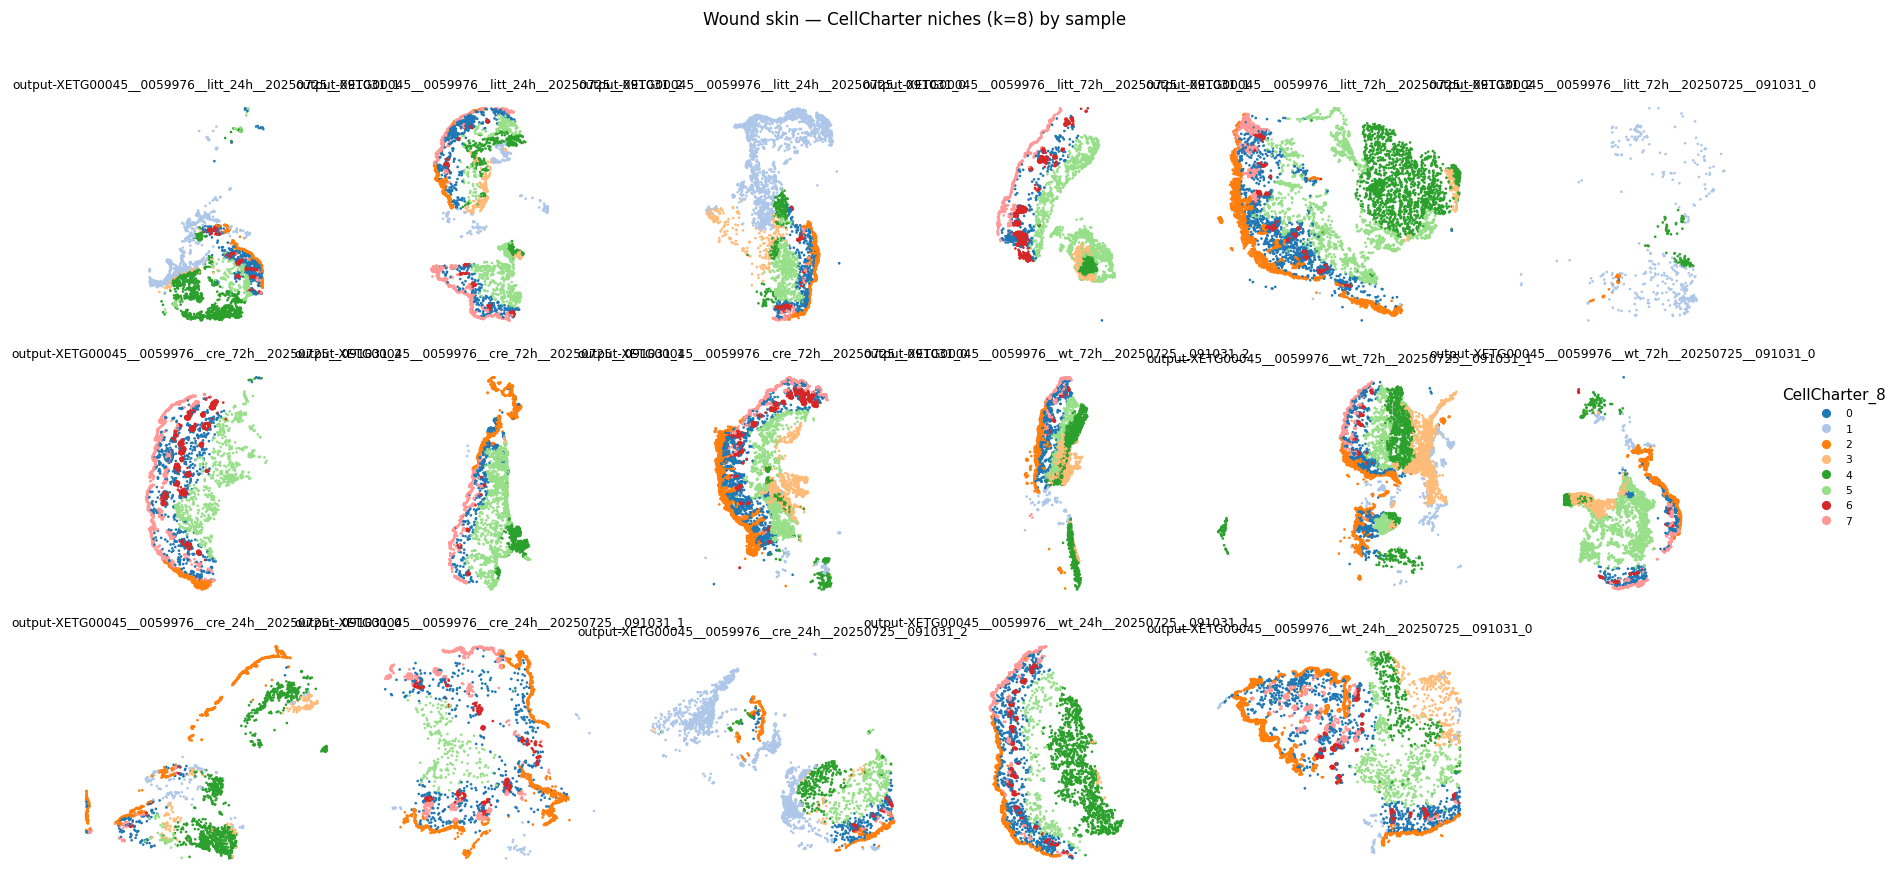

saved ../../results/spatial-tissue-maps/skin_wound_niches_k10_by_sample.png/.pdf


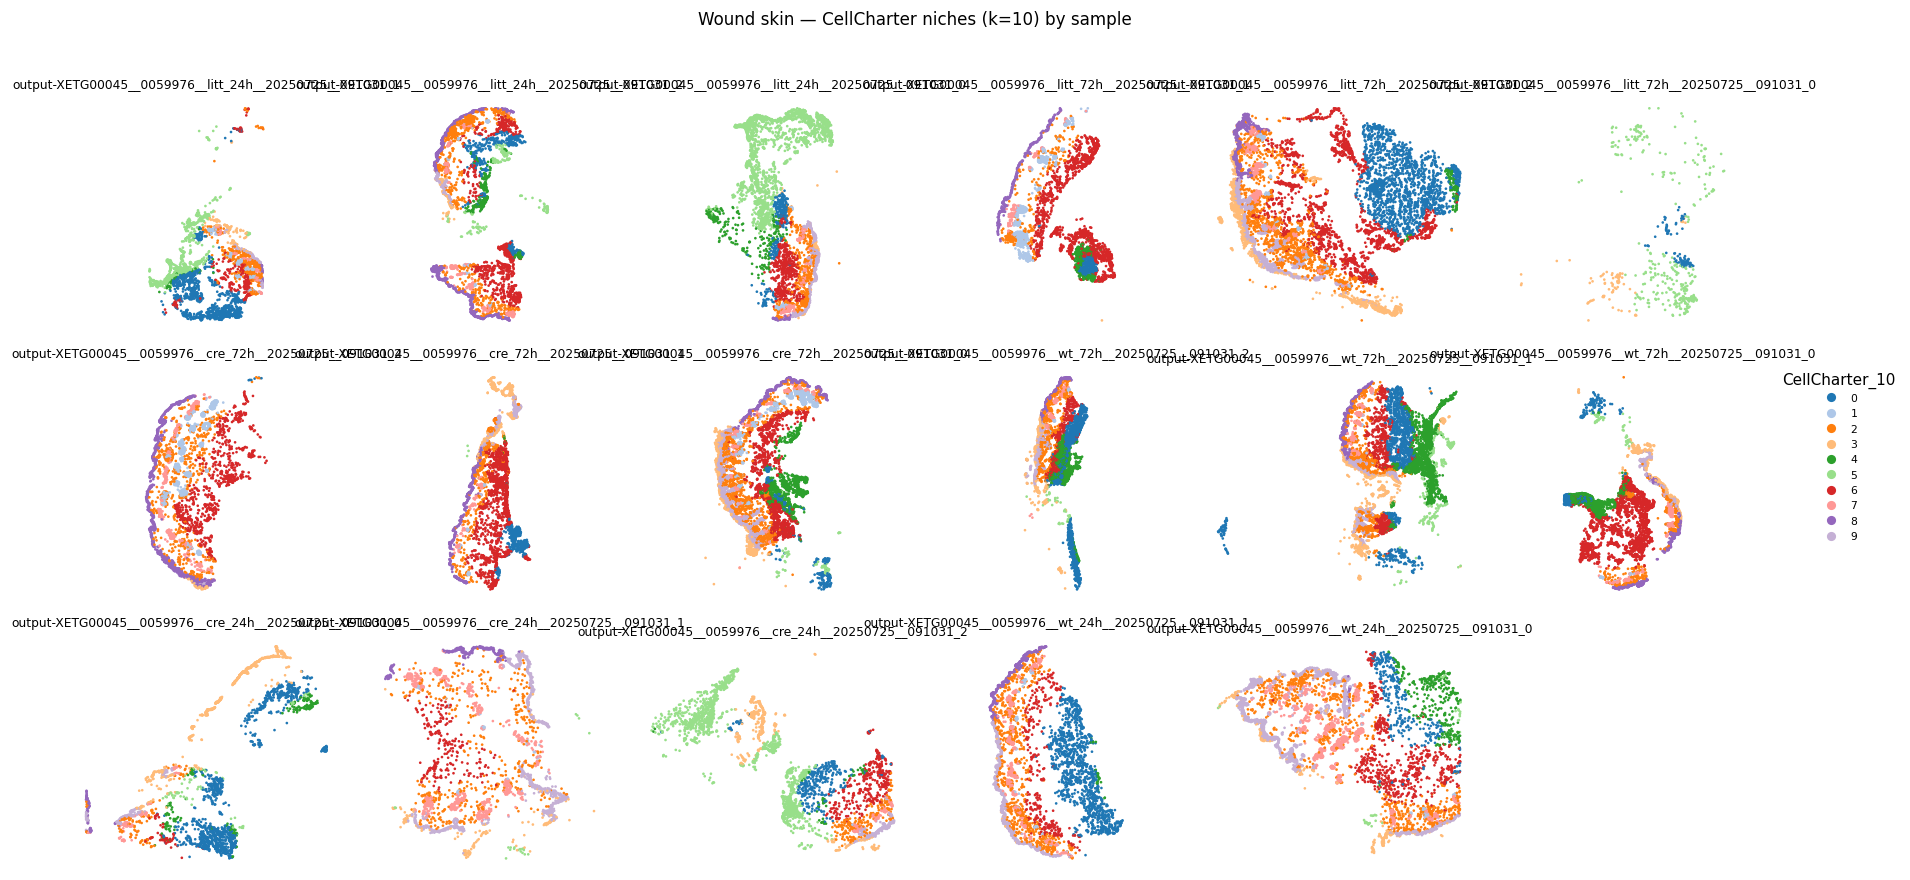

saved ../../results/spatial-tissue-maps/skin_wound_niches_k12_by_sample.png/.pdf


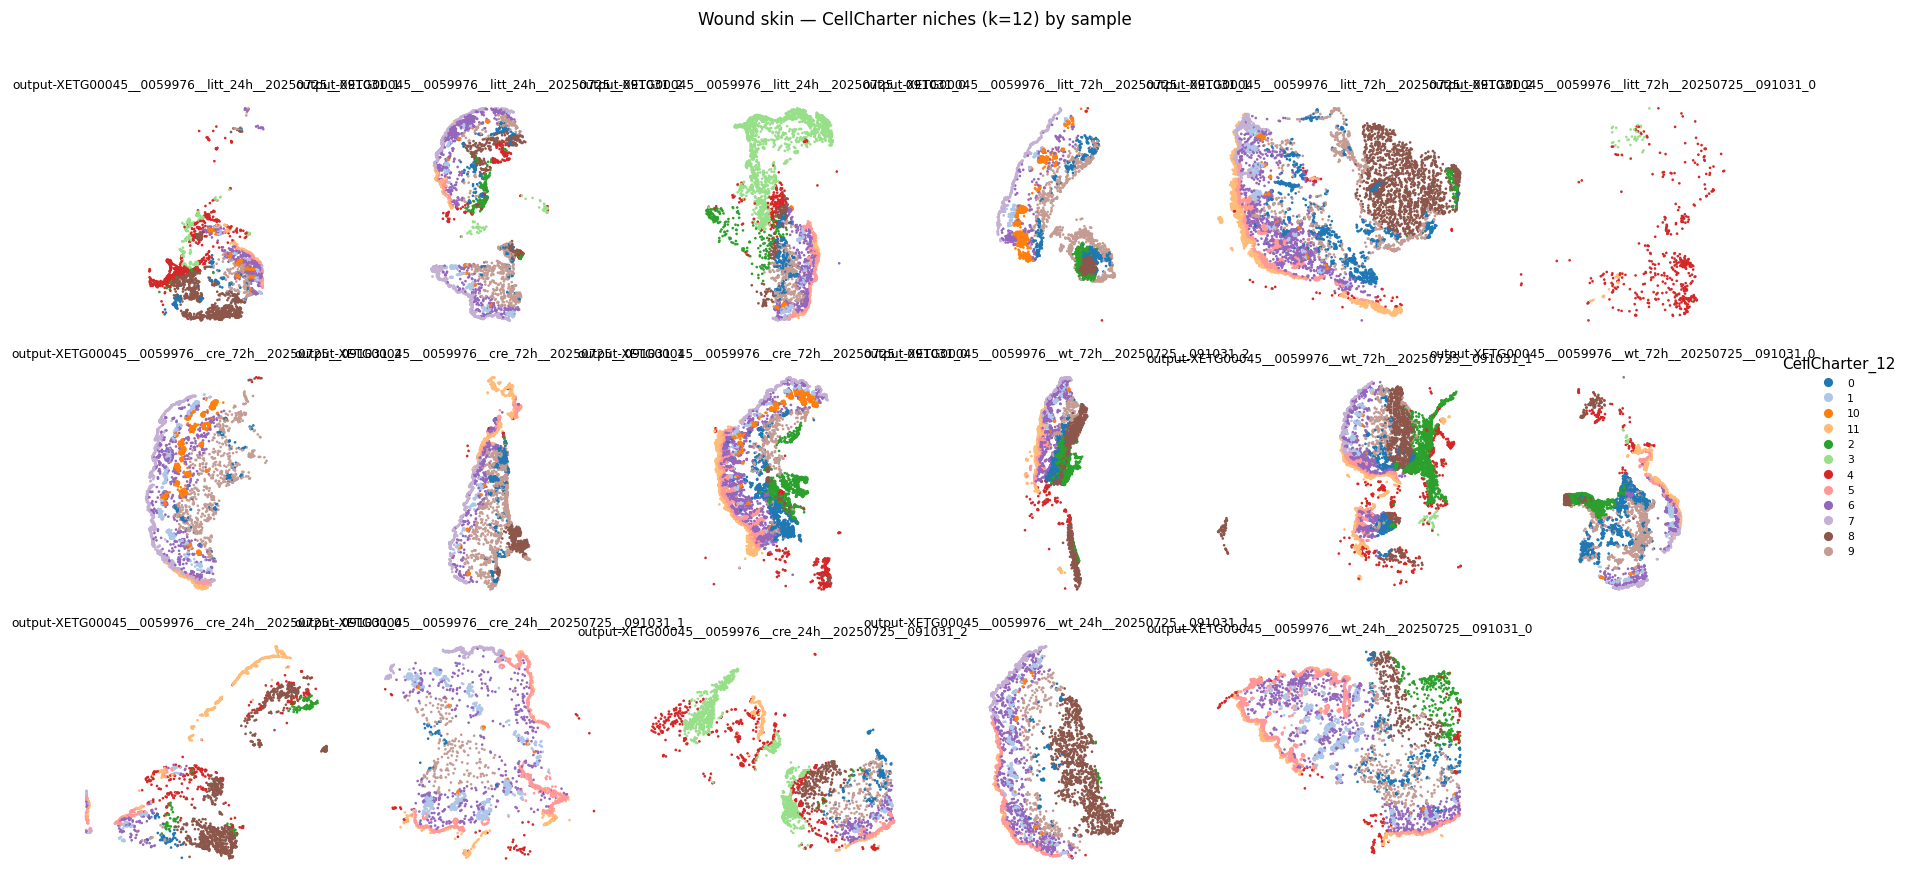

In [5]:
for k in KS:
    plot_niches_by_sample(
        adata, f'CellCharter_{k}',
        out_stem=f'../../results/spatial-tissue-maps/skin_wound_niches_k{k}_by_sample',
        title=f'Wound skin — CellCharter niches (k={k}) by sample')

## Spatial niche maps — per condition (6 panels)

In [6]:
def plot_niches_by_condition(ad, color, out_stem=None, spot_size=2.0, cols=3, title=None):
    coords = np.asarray(ad.obsm['spatial'])[:, :2]
    cats = ad.obs[color].astype('category')
    names = list(cats.cat.categories)
    codes = cats.cat.codes.to_numpy()
    base = list(plt.get_cmap('tab20').colors)
    col_list = (base * int(np.ceil(len(names) / len(base))))[:len(names)]
    rgba = np.array([mcolors.to_rgba(c) for c in col_list])
    conds = [c for c in ['litt_24h', 'cre_24h', 'wt_24h', 'litt_72h', 'cre_72h', 'wt_72h']
             if c in set(ad.obs['condition'].astype(str))]
    n = len(conds); ncol = min(cols, n); nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 3.4, nrow * 3.4), dpi=110)
    axes = np.atleast_1d(axes).ravel()
    cond = ad.obs['condition'].astype(str).to_numpy()
    for ax, cnd in zip(axes, conds):
        m = cond == cnd; cc = codes[m]
        ax.scatter(coords[m, 0], coords[m, 1], s=spot_size,
                   c=rgba[cc[cc >= 0]], linewidths=0, rasterized=True)
        ax.set_title(cnd, fontsize=9)
        ax.set_aspect('equal'); ax.invert_yaxis(); ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    handles = [Line2D([0], [0], marker='o', linestyle='', markersize=6,
                      markerfacecolor=rgba[i], markeredgewidth=0, label=nm)
               for i, nm in enumerate(names)]
    fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5),
               fontsize=7, frameon=False, title=color)
    if title:
        fig.suptitle(title, fontsize=11, y=1.02)
    fig.tight_layout()
    if out_stem:
        os.makedirs(os.path.dirname(out_stem), exist_ok=True)
        fig.savefig(out_stem + '.png', dpi=110, bbox_inches='tight')
        fig.savefig(out_stem + '.pdf', bbox_inches='tight')
        print('saved', out_stem + '.png/.pdf')
    plt.show()

saved ../../results/spatial-tissue-maps/skin_wound_niches_k8_by_condition.png/.pdf


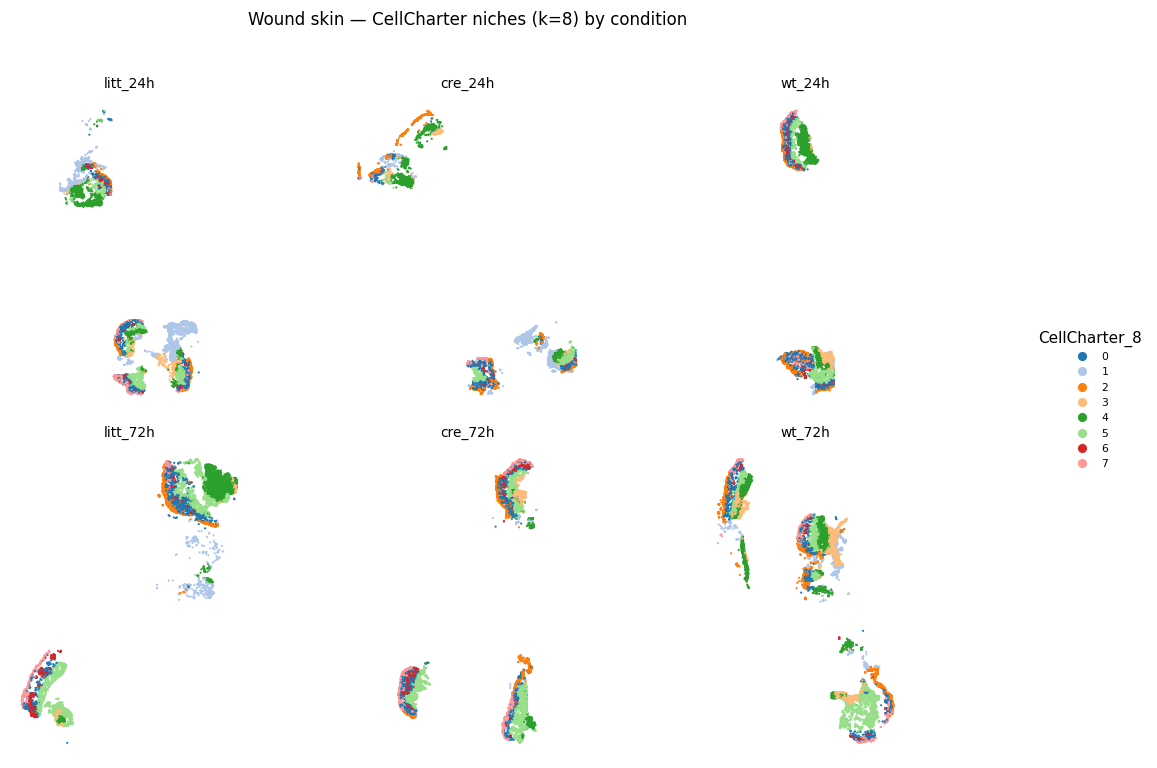

saved ../../results/spatial-tissue-maps/skin_wound_niches_k10_by_condition.png/.pdf


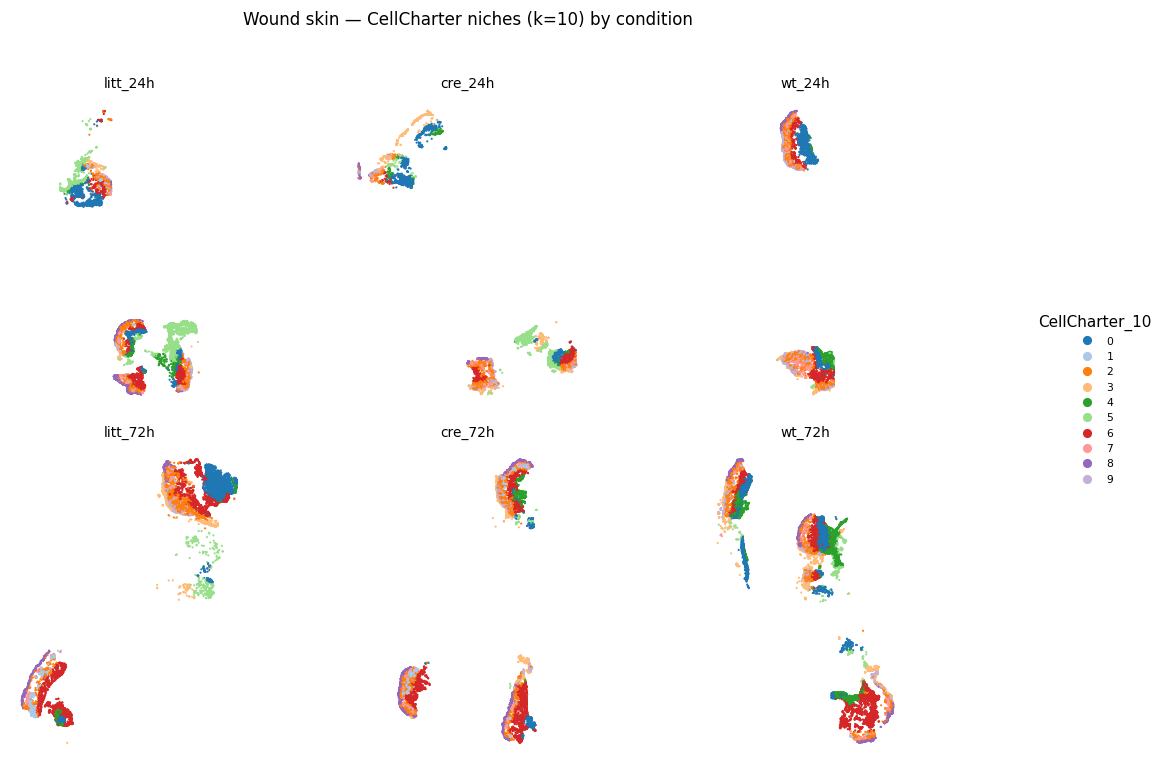

saved ../../results/spatial-tissue-maps/skin_wound_niches_k12_by_condition.png/.pdf


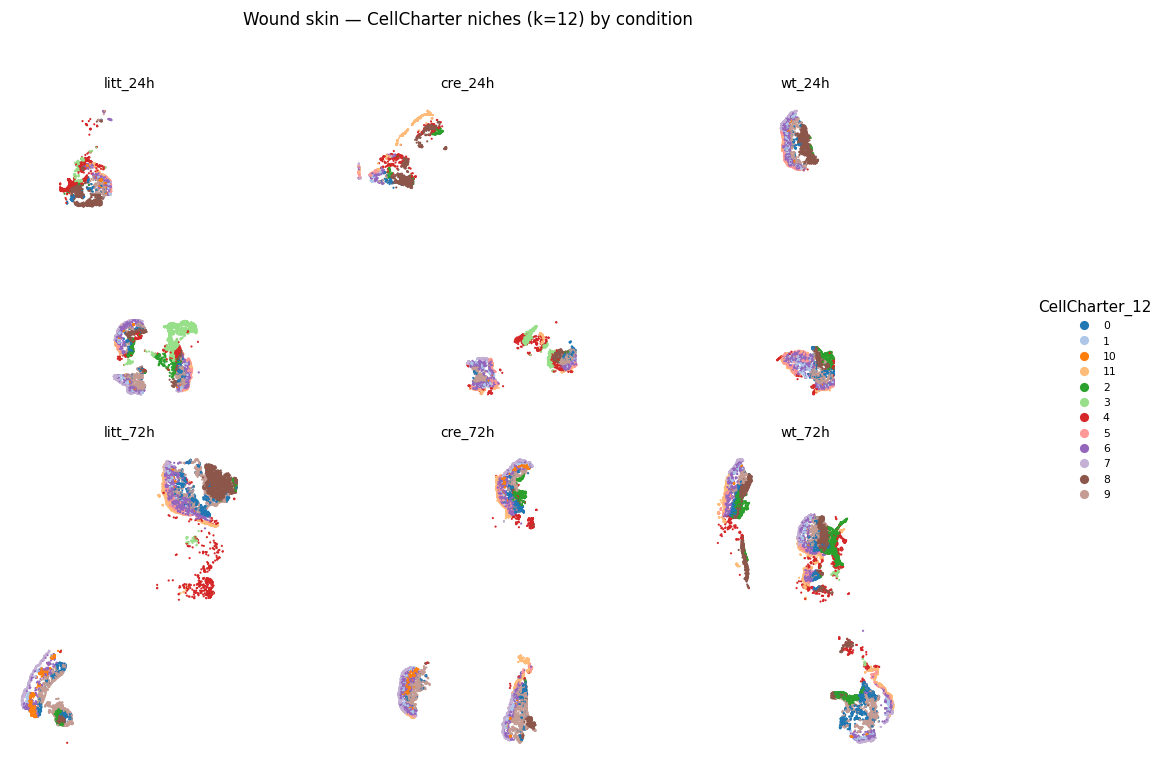

In [7]:
for k in KS:
    plot_niches_by_condition(
        adata, f'CellCharter_{k}',
        out_stem=f'../../results/spatial-tissue-maps/skin_wound_niches_k{k}_by_condition',
        title=f'Wound skin — CellCharter niches (k={k}) by condition')

## Niche × cell-type composition (best k) + per-cell export

In [8]:
best_k = 12
best_col = f'CellCharter_{best_k}'
sp = np.asarray(adata.obsm['spatial'])[:, :2]
per_cell = pd.DataFrame({
    'cell_id': adata.obs_names,
    'x': sp[:, 0], 'y': sp[:, 1],
    'sample_id': adata.obs['sample_id'].astype(str).values,
    'condition': adata.obs['condition'].astype(str).values,
    'genotype': adata.obs['genotype'].astype(str).values,
    'cell_type': adata.obs[ANNOT].astype(str).values,
})
for k in KS:
    per_cell[f'niche_k{k}'] = adata.obs[f'CellCharter_{k}'].astype(str).values
os.makedirs('../../results/cell-driven-analysis', exist_ok=True)
per_cell.to_csv('../../results/cell-driven-analysis/skin_wound_cell_niches.csv', index=False)

comp = pd.crosstab(adata.obs[best_col], adata.obs[ANNOT])
comp.to_csv(f'../../results/cell-driven-analysis/skin_wound_niche_composition_k{best_k}.csv')
print('wrote per-cell niche assignments and k=%d composition' % best_k)
comp.iloc[:, :6]

wrote per-cell niche assignments and k=12 composition


cytetype_annotation_leiden_4,Activated Dermal Fibroblast (Col1a2 ER-stress),Activated Dermal Fibroblast (TNC PRRX1),Activated Endothelial Cell,Activated Monocyte (CD11b+),Acute Graft-Response Macrophage,Arg1+ Macrophage
CellCharter_12,,,,,,
0,426,138,204,16,29,25
1,4,39,56,11,9,102
10,111,24,51,3,2,41
11,0,2,34,4,2,57
2,1216,32,67,12,97,22
3,0,0,118,26,95,65
4,21,29,163,21,114,88
5,1,2,52,7,6,52
6,285,1159,236,22,44,36


## Appendix — how the object was generated (already run, do not re-execute)

The cell below is the full CellCharter pipeline that produced
`talbot_xenium_skin_annotated_cellcharter.h5ad`. It is kept for reproducibility
only; **leave it unexecuted** unless you need to regenerate the object from
scratch (scVI training ~30 min on CPU).

In [9]:
# --- REFERENCE ONLY: do not run unless regenerating the object ---
# import scvi, squidpy as sq, cellcharter as cc
# from sklearn.mixture import GaussianMixture
# from lightning.pytorch import seed_everything
# seed_everything(12345); scvi.settings.seed = 12345
#
# adata = sc.read_h5ad('../../data/talbot_xenium_skin_annotated.h5ad')
# raw = sc.read_h5ad('../../data/talbot_xenium.h5ad')
# raw = raw[raw.obs.tissue != 'tumor']
# adata.layers['counts'] = raw[adata.obs_names].X.copy()
#
# scvi.model.SCVI.setup_anndata(adata, layer='counts', batch_key='sample_id')
# model = scvi.model.SCVI(adata)
# model.train(early_stopping=True, enable_progress_bar=True)
# adata.obsm['X_scVI'] = model.get_latent_representation(adata).astype(np.float32)
#
# sq.gr.spatial_neighbors(adata, library_key='sample_id', coord_type='generic',
#                         delaunay=True, percentile=99)
# cc.gr.aggregate_neighbors(adata, n_layers=3, use_rep='X_scVI',
#                           out_key='X_cellcharter', sample_key='sample_id')
#
# X = adata.obsm['X_cellcharter']; rows = []
# for k in KS:
#     gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=0, n_init=3)
#     adata.obs[f'CellCharter_{k}'] = pd.Categorical(gmm.fit_predict(X).astype(str))
#     rows.append({'k': k, 'bic': gmm.bic(X), 'aic': gmm.aic(X)})
# pd.DataFrame(rows).to_csv('../../results/cell-driven-analysis/skin_wound_cellcharter_gmm_sweep.csv', index=False)
# adata.write('../../data/talbot_xenium_skin_annotated_cellcharter.h5ad')